# Benthic fraction measurements

The `calc_benthic_fraction` measurement estimates the **areal cover of a target benthic class** in the neighbourhood around each focal annotation (e.g. a coral colony). For each annotation it:

1. lays a regular grid of sample points over an **annulus** around the colony (an inner radius excludes the colony itself);
2. finds the surface point and the best (occlusion-filtered) **camera image** that sees each sample;
3. classifies the image **crop** with a trained classifier; and
4. returns the **fraction** — or probability-weighted fraction — of samples that belong to the `target_class`.

This notebook loads a plot, runs the measurement across annotations, inspects the diagnostic visualizations, and exports the results.

In [1]:
%load_ext autoreload
%autoreload 2
import os
from substrata import *

## Load in the pointcloud and annotations and scale/orient using predefined saved world transform

Loading project from YAML file: /mnt/sdd/curacao_focal/cur_kal_40m_20200214/cur_kal_40m_20200214.yaml
Loading pointcloud from /mnt/sdd/curacao_focal/cur_kal_40m_20200214/cur_kal_40m_20200214_dec50M.ply
Loading cameras from /mnt/sdd/curacao_focal/cur_kal_40m_20200214/cur_kal_40m_20200214.meta.json and /mnt/sdd/curacao_focal/cur_kal_40m_20200214/cur_kal_40m_20200214.cams.xml
Loading markers from /mnt/sdd/curacao_focal/cur_kal_40m_20200214/cur_kal_40m_20200214_markers.csv
Loading annotations from /home/pimbongaerts/Github/substrata/sandbox/mcav_sint/annotations/cur_kal_40m_ann.csv
Applying world_transform to loaded objects:
[[ 6.91815870e-03  8.81985760e-02 -5.38114188e-02  1.49175200e+01]
 [-8.74792065e-02 -2.36954925e-02 -5.00842348e-02  2.53525065e+00]
 [-5.49731391e-02  4.88062839e-02  7.29274924e-02 -3.88472494e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


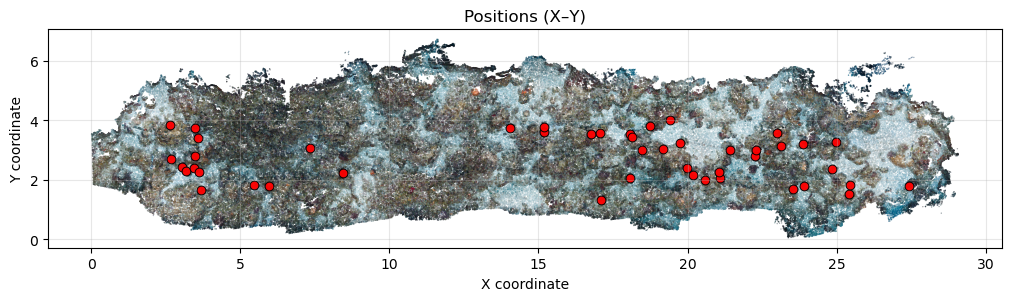

In [2]:
annotations_path = '/home/pimbongaerts/Github/substrata/sandbox/mcav_sint/annotations/'
output_path = '/home/pimbongaerts/Github/substrata/sandbox/mcav_sint/output/'

def load_plot_and_annotations(plot_path, annotations_path):
    plot = ProjectInitializer(path = plot_path)
    plot.reset_paths_to_local(plot_path)        # not required when running on server
    plot.annotations_filepath = annotations_path
    plot.initialize()
    return plot

# Example execution
plot = load_plot_and_annotations('/mnt/sdd/curacao_focal/cur_kal_40m_20200214/',
                                 os.path.join(annotations_path, 'cur_kal_40m_ann.csv'))
# Visualize annotations
plot.annotations.show(plot.pcd, color=True)

## Prepare for measurements and visualizations

In [3]:
# Load previously determined SA measurements
plot.annotations.load_measurements_from_csv("/home/pbongaerts/Github/substrata/sandbox/mcav_sint/annotations/all_SAs_clean.csv", id_column="sample_name")

# Correct camera path
plot.cams.set_filepath_replace("/home/deepcat/mounts/deepseal/coral3d/focal_plots/cur_kal/cur_kal_40m/",
                          "/mnt/sdd/curacao_focal/")

# Create buffered ortho to visualize annotation positions
ortho = OrthoMap(plot.pcd, pixel_width = 5000)

# Load classifier
benthic_classifier = classification.get_image_classifier('/home/pimbongaerts/Documents/annotations/benthic_annotations/tonga_only/crop_classifier.pkl', 'cuda')

The following CSV IDs had no matching annotation (skipped): MCCPKA05G0469_purple, MCCPKA05G0471_green, MCCPKA05G0473_green, MCCPKA05G0474_green, MCCPKA05G0475_green, MCCPKA10G0476_blue, MCCPKA10G0477_blue, MCCPKA10G0480_blue, MCCPKA10G0481_blue, MCCPKA10G0482_blue, MCCPKA10G0487_blue, MCCPKA10G0491_green, MCCPKA10G0493_green, MCCPKA10G0494_blue, MCCPKA10G0495_green, MCCPKA10G0497_green, MCCPKA10G0498_green, MCCPKA10G0499_blue, MCCPKA10G0500_blue, MCCPKA10G0501_green, MCCPKA10G0502_green, MCCPKA10G0503_blue, MCCPKA10G0505_blue, MCCPKA20G0292_green, MCCPKA20G0293_blue, MCCPKA20G0311_blue, MCCPKA20G0312_blue, MCCPKA20G0315_blue, MCCPKA20G0318_green, MCCPKA20G0321_green, MCCPKA20G0329_blue, MCCPKA20G0330_blue, MCCPKA20G0334_blue, MCCPKA20G0386_blue, MCCPKA20G0388_green, MCCPKA20G0390_blue, MCCPKA20G0394_blue, MCCPKA20G0395_blue, MCCPKA20G0396_blue, MCCPKA20G0398_blue, MCCPKA20G0399_blue, MCCPKA20G0400_blue, MCCPKA20G0404_blue, MCCPKA20G0405_green, MCCPKA20G0406_blue, MCCPKA20G0507_blue, MC

## Calculate and visualize the benthic fraction

`calc_benthic_fraction` reuses the same annulus neighbourhood as `calc_tpi_and_tri`: an **inner radius** excludes the focal colony and an **outer limit** (`radius_outer` or `annulus_width`) bounds the sampled ring. A regular grid of points at `sample_spacing` is sampled within the ring; for each, the surface intercept is found, the best (occlusion-filtered) camera image is matched, and the crop centred on that pixel is classified.

The returned metric is either the **fraction of samples** classified as `target_class` (`weight_by_probability=False`), or the **mean predicted probability** of `target_class` across samples (`weight_by_probability=True`).

**Prerequisites** (run once per annotation set):

- `get_radius_from_2D_surface_area()` — sets each annotation's `radius`, used as the inner radius so the colony is excluded from sampling.
- `get_first_image_matches(cams)` — matches each colony to its best image; this match is reused as the colony shown in the inner circle of the visualization (so no extra intercept is computed).

**Key arguments:**

- `target_class` — benthic class code to measure (e.g. `"SU"`).
- `annulus_width` / `radius_outer` — outer extent of the ring (mutually exclusive); `radius_inner` defaults to the annotation's colony radius.
- `sample_spacing` — grid spacing in metres; finer spacing = more samples (slower).
- `weight_by_probability` — probability-weighted vs. hard-count fraction.
- `generate_image` — render the sample-dots visualization.
- `show_image_matches` — also render the combined dots-vs-crops troubleshooting plot (stored as the measurement image).
- `batch_size` — classifier inference batch size.

Results are stored on each annotation's `measurements` dict: `benthic_fraction`, `benthic_target_class`, `benthic_n_classified`, `benthic_n_target`, plus the visualization image(s).

> **GPU / speed:** classification runs in batched passes and prints the device it used (e.g. `... on cuda (GPU, batch_size=64)`). Load the classifier on the GPU with `classification.get_image_classifier(path, 'cuda')`. Decoding the full-resolution source photos for the crops is usually the dominant cost and is parallelised across CPU threads.

In [9]:
# Calculate benthic fraction for the first 5 annotations
annotations = plot.annotations.subset(5)

annotations.get_first_image_matches(plot.cams)

# Sample point cloud around annotations with 0.5m cylinder radius buffer (= beyond the colony radius)
annotations.get_radius_from_2D_surface_area()
annotations.get_point_cloud_by_radius(plot.pcd, cylinder=True, radius_buffer=0.5)

annotations.measure_all(
    measurements.calc_benthic_fraction,
    plot.pcd, plot.cams, benthic_classifier, "SU",
    annulus_width=0.2,
    sample_spacing=0.05,
    base_falloff_depth=0.05,
    weight_by_probability=True,
    generate_image=True,
    show_image_matches = True
)

Getting first image matches:   0%|          | 0/5 [00:00<?, ?it/s]

Subsampling pointcloud for each annotation:   0%|          | 0/5 [00:00<?, ?it/s]

Conducting <function calc_benthic_fraction at 0x7c7acd18b760> measurement for all annotations...:   0%|       …

  0%|          | 0/88 [00:00<?, ?it/s]

Intercept points returned: 88/88
Classifying 88 image match(es) on cuda (GPU, batch_size=64)


...

Intercept points returned: 92/92
Classifying 92 image match(es) on cuda (GPU, batch_size=64)


Cropping image matches (cuda):   0%|          | 0/92 [00:00<?, ?img/s]

  0%|          | 0/68 [00:00<?, ?it/s]

Intercept points returned: 68/68
Classifying 68 image match(es) on cuda (GPU, batch_size=64)


Cropping image matches (cuda):   0%|          | 0/68 [00:00<?, ?img/s]

### Inspecting the results

With `show_image_matches=True` the measurement stores a **combined comparison plot** as the measurement image. The **left panel** shows the classified sample points (in weighted mode their red intensity encodes `P(target_class)`) over the colony's true-colour point cloud; the **right panel** shows, at the same positions, the actual image crops fed to the classifier (border colour matches the dots), with the colony itself filling the inner circle. Comparing the two panels point-for-point makes it easy to tell a **classifier error** (the crop clearly shows the target but is mislabelled) from a **method error** (the crop is not on the sampled feature).

Display any stored measurement images (keys ending in `_image`) with `show_measurement_images()`:

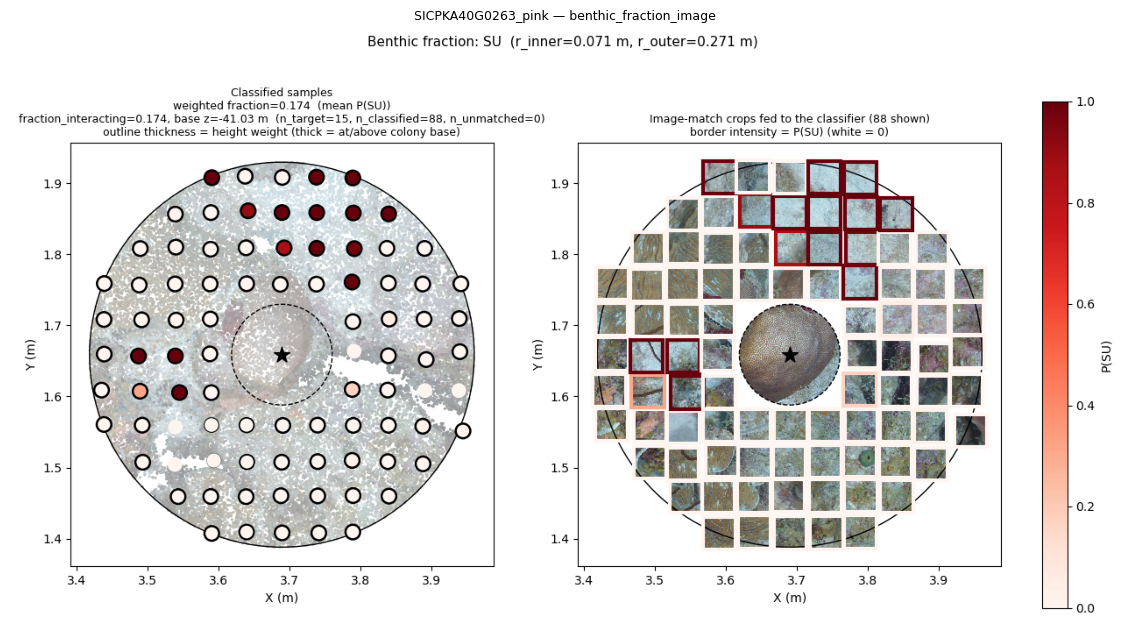

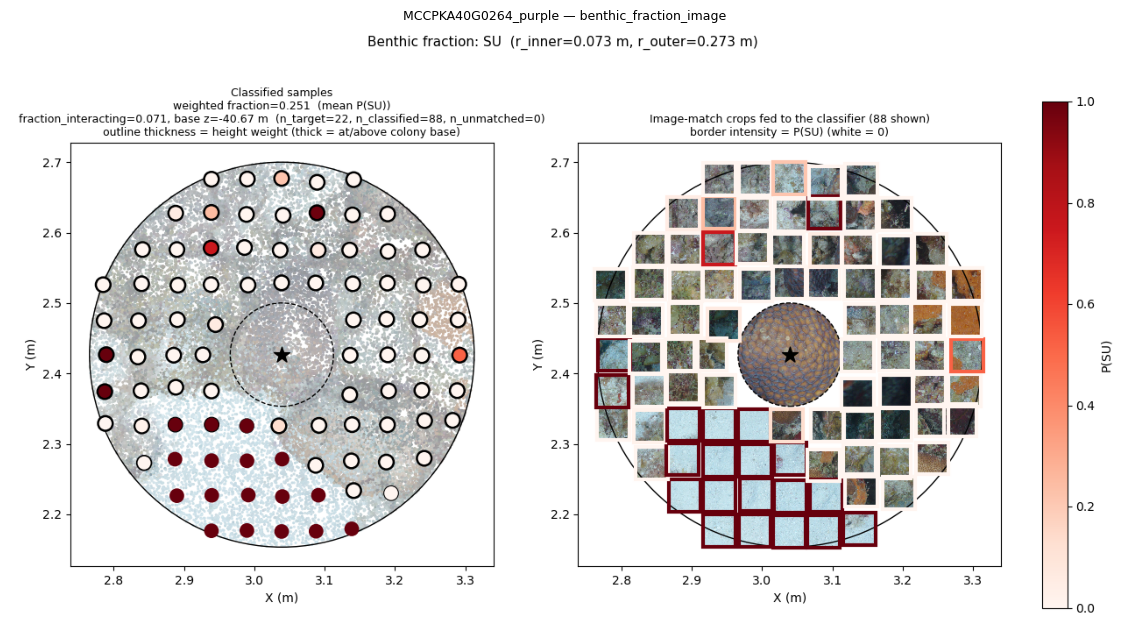

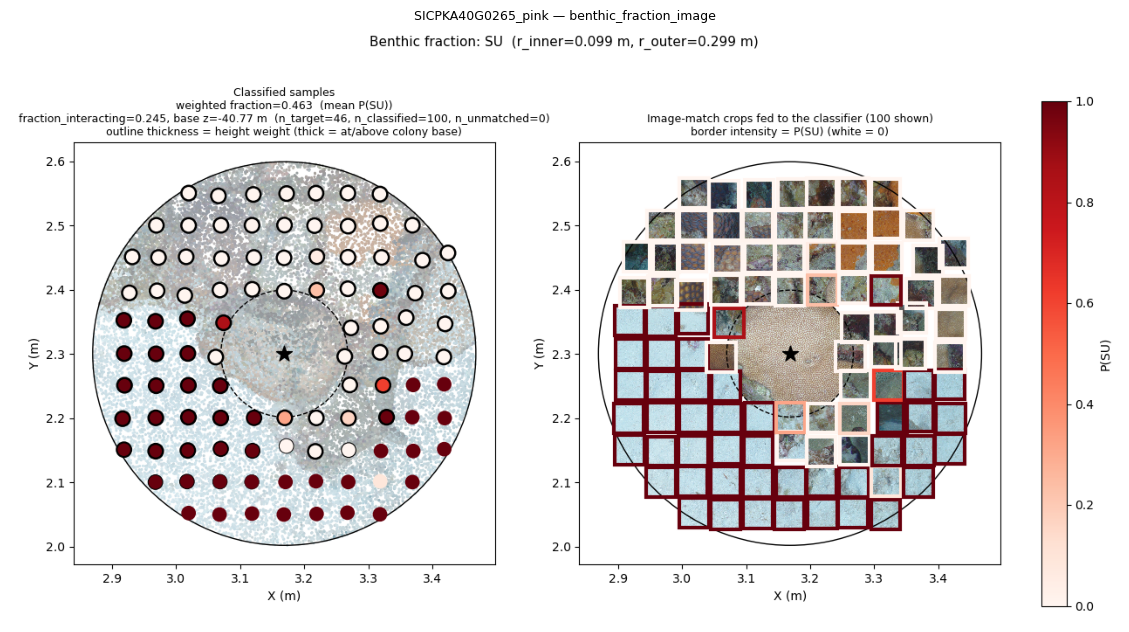

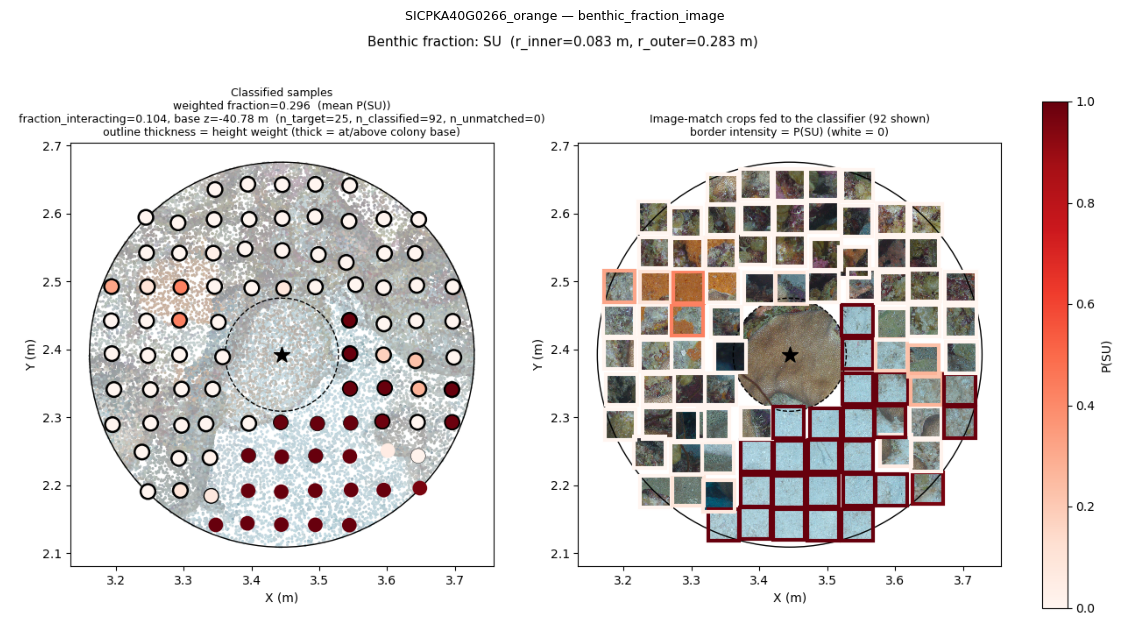

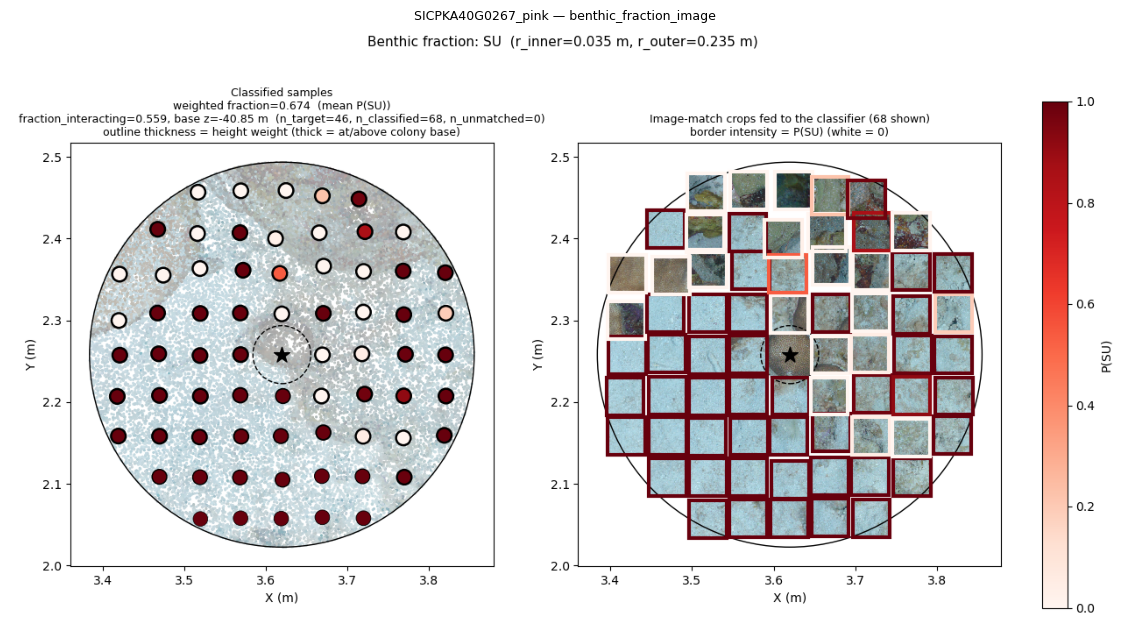

In [10]:
for ann in annotations:
    ann.show_measurement_images()

### Exporting a report

Combine the per-annotation visualizations (orthomap, colony images and crops) into a single PDF report:

In [30]:
# Output measurement visualizations to PDF (with ortho and images/crops)
visualizations.save_measurement_visualizations_to_pdf(annotations, 
                                                      '/home/pimbongaerts/Github/substrata/docs/notebooks/sand_fraction_report.pdf',
                                                      orthomap=ortho)

Annotations 'up_vector' and/or depth_offset not set
Created circular mask 1: radius 0.0709 m
Center: (6219, 3254), radius: 346 px
Mask area: 376081 pixels = 0.0158 m²


Rasterizing (447x447 px): 100%|███████████████████████████████████████████████████████| 101/101 [00:00<00:00, 12260.14it/s]


Annotations 'up_vector' and/or depth_offset not set
Created circular mask 1: radius 0.0734 m
Center: (5767, 3075), radius: 430 px
Mask area: 580833 pixels = 0.0169 m²


Rasterizing (447x447 px): 100%|████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 9525.44it/s]


Annotations 'up_vector' and/or depth_offset not set
Created circular mask 1: radius 0.0988 m
Center: (2917, 2855), radius: 515 px
Mask area: 833189 pixels = 0.0307 m²


Rasterizing (447x447 px): 100%|████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 9493.63it/s]


Annotations 'up_vector' and/or depth_offset not set
Created circular mask 1: radius 0.0833 m
Center: (3272, 3456), radius: 389 px
Mask area: 475337 pixels = 0.0218 m²


Rasterizing (447x447 px): 100%|████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 8890.71it/s]


Annotations 'up_vector' and/or depth_offset not set
Created circular mask 1: radius 0.0355 m
Center: (4767, 2904), radius: 145 px
Mask area: 66045 pixels = 0.0039 m²


Rasterizing (447x447 px): 100%|███████████████████████████████████████████████████████| 101/101 [00:00<00:00, 11007.53it/s]


## Production run over all annotations

For a run over many annotations, switch off the per-annotation images (`generate_image=False`, `show_image_matches=False`) to keep it fast, then summarise the resulting `benthic_fraction` across the plot. Other knobs worth tuning: use `radius_outer` instead of `annulus_width` to fix an absolute outer extent, a coarser `sample_spacing` for speed, and a larger `batch_size` for more GPU throughput.

Subsampling pointcloud for each annotation:   0%|          | 0/46 [00:00<?, ?it/s]

Conducting <function calc_benthic_fraction at 0x7f4bb246b520> measurement for all annotations...:   0%|       …

  0%|          | 0/88 [00:00<?, ?it/s]

Intercept points returned: 88/88
Classifying 88 image match(es) on cuda (GPU, batch_size=64)


Cropping image matches (cuda):   0%|          | 0/88 [00:00<?, ?img/s]

...

Intercept points returned: 68/68
Classifying 68 image match(es) on cuda (GPU, batch_size=64)


Cropping image matches (cuda):   0%|          | 0/68 [00:00<?, ?img/s]

  0%|          | 0/68 [00:00<?, ?it/s]

Intercept points returned: 68/68
Classifying 68 image match(es) on cuda (GPU, batch_size=64)


Cropping image matches (cuda):   0%|          | 0/68 [00:00<?, ?img/s]

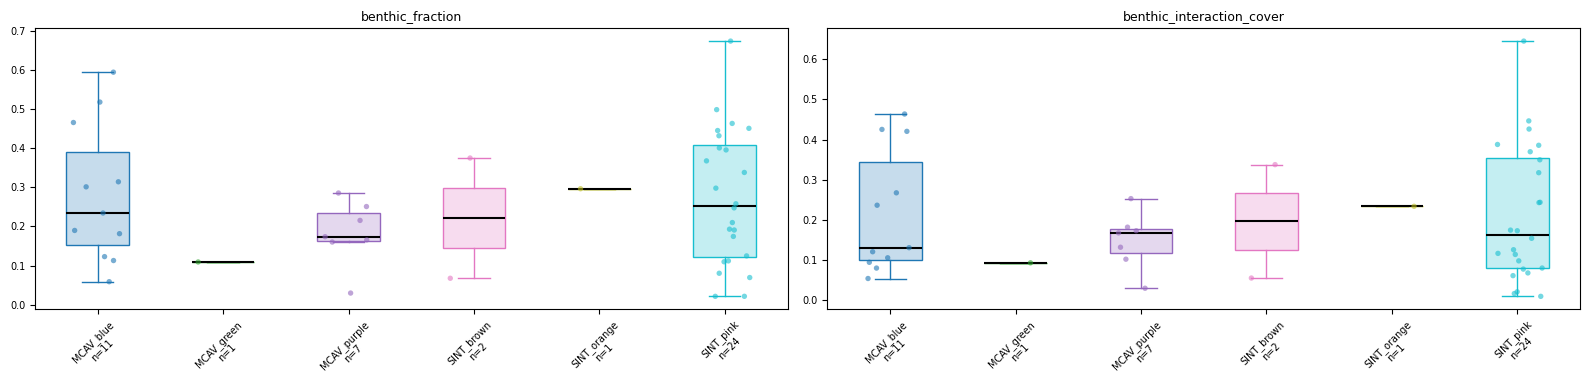

In [12]:
# Calculate across all annotations in plot
annotations = plot.annotations

# Sample point cloud around annotations with 0.7m cylinder radius
annotations.get_radius_from_2D_surface_area()
annotations.get_point_cloud_by_radius(plot.pcd, cylinder=True, radius_buffer=0.5)

annotations.measure_all(
    measurements.calc_benthic_fraction,
    plot.pcd, plot.cams, benthic_classifier, "SU",
    annulus_width=0.2,
    sample_spacing=0.05,
    weight_by_probability=True,
    generate_image=False,
    show_image_matches = False
)

fig = visualizations.plot_measurements(annotations, measurements=["benthic_fraction", "benthic_interaction_cover" ])

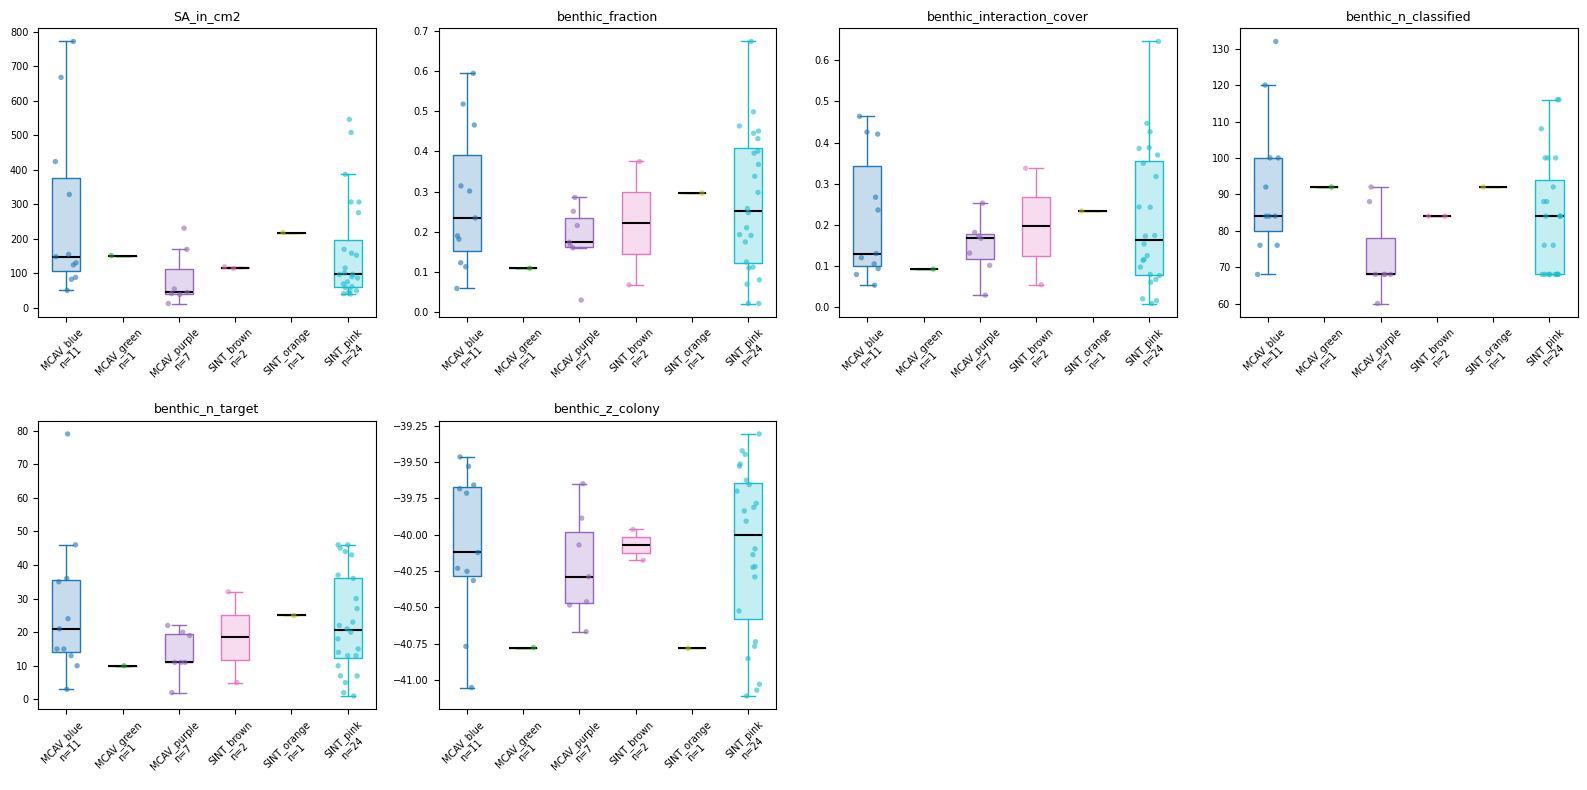

In [13]:
fig = visualizations.plot_measurements(annotations)